# 3.9b — Compression par élagage : le réseau amputé qui tient

`3.9` a montré qu'on peut **réduire la précision** des nombres. `3.9a` a montré qu'on peut
**réduire le nombre de codes** en quantifiant. Ce notebook couvre la troisième famille de
compression, celle qui **supprime des poids** :

| famille | ce qu'on enlève | où |
|---|---|---|
| quantization FP | des bits de mantisse | `3.9` |
| quantization INT | des niveaux de quantification | `3.9a` |
| **élagage (pruning)** | **des poids, puis des filtres entiers** | **ce notebook** |

L'idée est brutale et ancienne : dans un réseau entraîné, la plupart des poids sont
**petits**. Si un poids petit peut être mis à zéro sans que la sortie bouge, alors il ne
servait à rien. Trois questions structurent le notebook, et chacune se tranche par une
**mesure**, pas par une intuition :

1. Jusqu'où peut-on mettre à zéro avant que l'exactitude s'effondre ?
2. Un réseau « à 90 % de zéros » est-il **plus petit** ? (la réponse est non, et c'est le
   piège central de tout le domaine)
3. Après avoir coupé, **réentraîner** — et même **réinitialiser** — permet-il de retrouver
   l'exactitude perdue ?

## Le contrat de ce notebook

- **§1–§8 sont écrits à la main.** Pas de `torch.nn.utils.prune`, pas de
  `torch.ao.pruning` : le masque, le critère de sélection et la reconstruction du réseau
  sont dans les cellules ci-dessous — même posture que `3.9` (pas de `torch.quantization`).
  Le §9 fait ensuite entrer l'outil standard **en contrepoint** : la main pour comprendre,
  la bibliothèque pour produire.
- **Le terrain est celui de `3.9a`** : le même ResNet-20, les mêmes 50 000 images CIFAR-10,
  la même recette. Conséquence voulue : les chiffres d'élagage et de quantification sont
  comparables, parce qu'ils portent sur le même réseau.
- **Chaque affirmation est mesurée.** Les cellules `**Lecture.**` ne commentent que ce que
  la sortie ci-dessus imprime.
- **Le budget d'entraînement est explicite.** La recette complète (40 époques) sert à
  obtenir le réseau de référence. Les bras de réentraînement utilisent un budget **réduit et
  déclaré** : comparer six variantes à 40 époques chacune coûterait des heures pour un
  ordre de grandeur déjà lisible à 10. Le budget est affiché, jamais caché.

In [1]:
import copy
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 40 if DEV == "cuda" else 6        # recette de reference (comme 3.9a)
EPOCHS_FT = 10 if DEV == "cuda" else 3     # budget reduit des bras de reentrainement
print(f"device={DEV}  torch={torch.__version__}  epochs={EPOCHS}  epochs_ft={EPOCHS_FT}")

device=cuda  torch=2.8.0+cu126  epochs=40  epochs_ft=10


## 1. Le terrain : le même ResNet-20 que `3.9a`

On reprend **à l'identique** le réseau et les données de `3.9a`. Ce n'est pas de la paresse :
c'est ce qui rend les deux notebooks comparables. Un réseau différent aurait rendu toute
comparaison entre élagage et quantification impossible.

Le cache de données est le cache **partagé** du dépôt (`~/.cache/coursia-datasets`), pas un
cache par notebook : le terrain est le même pour toute la série.

In [2]:
DATA = os.path.join(os.path.expanduser("~"), ".cache", "coursia-datasets")
norm = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
tfm = transforms.Compose([transforms.ToTensor(), norm])
tfm_train = transforms.Compose([transforms.RandomCrop(32, padding=4),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(), norm])
train_set = datasets.CIFAR10(DATA, train=True, download=True, transform=tfm_train)
test_set = datasets.CIFAR10(DATA, train=False, download=True, transform=tfm)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=512, shuffle=False)
print(f"CIFAR-10 : {len(train_set)} train / {len(test_set)} test")

CIFAR-10 : 50000 train / 10000 test


In [3]:
class BasicBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.short = None
        if stride != 1 or cin != cout:
            self.short = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride=stride, bias=False), nn.BatchNorm2d(cout))

    def forward(self, x):
        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        y = y + (self.short(x) if self.short is not None else x)
        return F.relu(y)


class ResNet20(nn.Module):
    def __init__(self, nclass=10):
        super().__init__()
        self.stem = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn0 = nn.BatchNorm2d(16)
        self.s1 = self._stage(16, 16, 3, 1)
        self.s2 = self._stage(16, 32, 3, 2)
        self.s3 = self._stage(32, 64, 3, 2)
        self.fc = nn.Linear(64, nclass)

    @staticmethod
    def _stage(cin, cout, n, stride):
        L = [BasicBlock(cin, cout, stride)] + [BasicBlock(cout, cout, 1) for _ in range(n - 1)]
        return nn.Sequential(*L)

    def forward(self, x):
        x = F.relu(self.bn0(self.stem(x)))
        x = self.s3(self.s2(self.s1(x)))
        return self.fc(F.adaptive_avg_pool2d(x, 1).flatten(1))


model = ResNet20().to(DEV)
n_par = sum(p.numel() for p in model.parameters())
n_conv = sum(1 for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear)))
print(f"ResNet-20 : {n_par:,} parametres, {n_conv} couches conv/fc")

ResNet-20 : 272,474 parametres, 22 couches conv/fc


L'entraînement suit la recette canonique ResNet-CIFAR — SGD avec momentum, décroissance
cosinus du pas, augmentation par recadrage aléatoire et retournement horizontal. On garde
une copie du **state_dict d'initialisation** : c'est lui qui servira au bras « loterie » de
la section 7, où l'on réinitialise les poids survivants au lieu de les réentraîner.

In [4]:
init_state = copy.deepcopy(model.state_dict())

opt = torch.optim.SGD(model.parameters(), lr=0.08, momentum=0.9, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
t_start = time.perf_counter()
for ep in range(EPOCHS):
    model.train()
    t0 = time.perf_counter()
    for x, y in train_loader:
        loss = F.cross_entropy(model(x.to(DEV)), y.to(DEV))
        opt.zero_grad(); loss.backward(); opt.step()
    sched.step()
    if ep == 0 or (ep + 1) % 10 == 0:
        print(f"  ep {ep+1:2d}/{EPOCHS}  loss={loss.item():.4f}  ({time.perf_counter()-t0:.1f}s)")
print(f"entrainement de reference : {time.perf_counter()-t_start:.1f}s")

  ep  1/40  loss=1.3291  (18.9s)


  ep 10/40  loss=0.4343  (16.5s)


  ep 20/40  loss=0.3600  (14.9s)


  ep 30/40  loss=0.2482  (17.6s)


  ep 40/40  loss=0.0905  (15.4s)
entrainement de reference : 648.4s


In [5]:
def evaluate(m, loader):
    m.eval()
    good = tot = 0
    with torch.no_grad():
        for x, y in loader:
            good += (m(x.to(DEV)).argmax(1).cpu() == y).sum().item()
            tot += y.numel()
    return good / tot


def macs_millions(m, shape=(1, 3, 32, 32)):
    """MACs d'une passe avant, comptes a la main depuis les formes de sortie."""
    total = 0
    handles = []

    def hook(mod, inp, out):
        nonlocal total
        if isinstance(mod, nn.Conv2d):
            kh, kw = mod.kernel_size
            total += out.shape[1] * out.shape[2] * out.shape[3] * (mod.in_channels // mod.groups) * kh * kw
        elif isinstance(mod, nn.Linear):
            total += mod.in_features * out.shape[1]

    for mod in m.modules():
        if isinstance(mod, (nn.Conv2d, nn.Linear)):
            handles.append(mod.register_forward_hook(hook))
    m.eval()
    with torch.no_grad():
        m(torch.zeros(*shape, device=DEV))
    for h in handles:
        h.remove()
    return total / 1e6


acc_ref = evaluate(model, test_loader)
macs_ref = macs_millions(model)
print(f"[reference] exactitude test = {acc_ref:.4f}   MACs = {macs_ref:.2f} M   poids = {n_par:,}")

[reference] exactitude test = 0.8980   MACs = 40.81 M   poids = 272,474


## 2. Le vocabulaire : un masque, une mesure

Élaguer, c'est multiplier les poids par un **masque** binaire — `1` on garde, `0` on coupe.
Tout le reste du domaine n'est qu'un choix de **critère** pour décider où sont les zéros, et
de **granularité** pour décider ce qu'on coupe ensemble.

Deux mesures vont nous suivre partout, et il faut les distinguer dès maintenant :

- la **sparsité** : la fraction de poids à zéro — c'est ce qu'on croit avoir gagné ;
- le **nombre de poids non nuls** : ce qui reste réellement à calculer.

La section 4 montrera que ces deux nombres ne suffisent pas à décrire la taille d'un modèle —
mais ils sont le point de départ.

In [6]:
def weight_modules(m):
    """Les couches porteuses de poids : conv et fc. Les BatchNorm sont hors du compte."""
    return [(name, mod) for name, mod in m.named_modules()
            if isinstance(mod, (nn.Conv2d, nn.Linear))]


def sparsity(m):
    nz = tot = 0
    for _, mod in weight_modules(m):
        tot += mod.weight.numel()
        nz += int((mod.weight != 0).sum())
    return 1.0 - nz / tot


def nonzero_params(m):
    return sum(int((mod.weight != 0).sum()) for _, mod in weight_modules(m))


def zero_tiny_(m):
    """Remet a zero exactement les poids deja nuls par un masque (bruit flottant)."""
    with torch.no_grad():
        for _, mod in weight_modules(m):
            mod.weight.data[mod.weight.data.abs() < 1e-12] = 0.0
    return m

## 3. Élagage non structuré : couper les plus petits poids

Le critère le plus simple, et le plus difficile à battre : **la magnitude**. Un poids petit
contribue peu à la sortie ; on garde les `k` plus grands en valeur absolue et on annule le
reste. Le `kthvalue` ci-dessous donne exactement le seuil du k-ième plus grand — pas de tri
complet, pas d'approximation.

Deux granularités, qui ne se valent pas :

- **par couche** : chaque couche garde `k%` de **ses** poids. Le taux est respecté localement,
  mais une couche peu sensible se retrouve élaguée autant qu'une couche critique.
- **globale** : un seul seuil pour tout le réseau. Les couches sensibles sont épargnées,
  les couches redondantes sont rasées.

Le masque est appliqué **après** le calcul du seuil, et on mesure l'exactitude **sans
réentraîner** : c'est la perte brute, celle qu'il faudra ensuite récupérer.

In [7]:
def threshold_keep(w, keep_frac):
    """Masque binaire : garde les |w| >= seuil du k-ieme plus grand."""
    flat = w.detach().abs().flatten()
    k = max(1, int(round(keep_frac * flat.numel())))
    if k >= flat.numel():
        return torch.ones_like(w)
    thr = torch.kthvalue(flat, flat.numel() - k + 1).values
    return (w.detach().abs() >= thr).to(w.dtype)


def prune_unstructured_(m, keep_frac, mode="layer"):
    """Applique un masque de magnitude, par couche ou global. Modifie m en place."""
    mods = weight_modules(m)
    if mode == "layer":
        masks = {name: threshold_keep(mod.weight.data, keep_frac) for name, mod in mods}
    elif mode == "global":
        allw = torch.cat([mod.weight.data.detach().abs().flatten() for _, mod in mods])
        k = max(1, int(round(keep_frac * allw.numel())))
        thr = torch.kthvalue(allw, allw.numel() - k + 1).values
        masks = {name: (mod.weight.data.detach().abs() >= thr).to(mod.weight.dtype)
                 for name, mod in mods}
    else:
        raise ValueError(mode)
    with torch.no_grad():
        for name, mod in mods:
            mod.weight.data.mul_(masks[name])
    return masks

In [8]:
LEVELS = [0.0, 0.5, 0.8, 0.9, 0.95]
grid = {}
for mode in ("layer", "global"):
    for keep in LEVELS:
        m = copy.deepcopy(model)
        masks = prune_unstructured_(m, keep, mode)
        grid[(mode, keep)] = (evaluate(m, test_loader), sparsity(m))
    print(f"{mode:7s} " + "  ".join(
        f"k={k:.2f}:acc={grid[(mode, k)][0]:.4f}/sp={grid[(mode, k)][1]:.3f}" for k in LEVELS))

layer   k=0.00:acc=0.1000/sp=1.000  k=0.50:acc=0.7779/sp=0.500  k=0.80:acc=0.8956/sp=0.200  k=0.90:acc=0.8970/sp=0.100  k=0.95:acc=0.8970/sp=0.050


global  k=0.00:acc=0.1000/sp=1.000  k=0.50:acc=0.8802/sp=0.500  k=0.80:acc=0.8964/sp=0.200  k=0.90:acc=0.8979/sp=0.100  k=0.95:acc=0.8986/sp=0.050


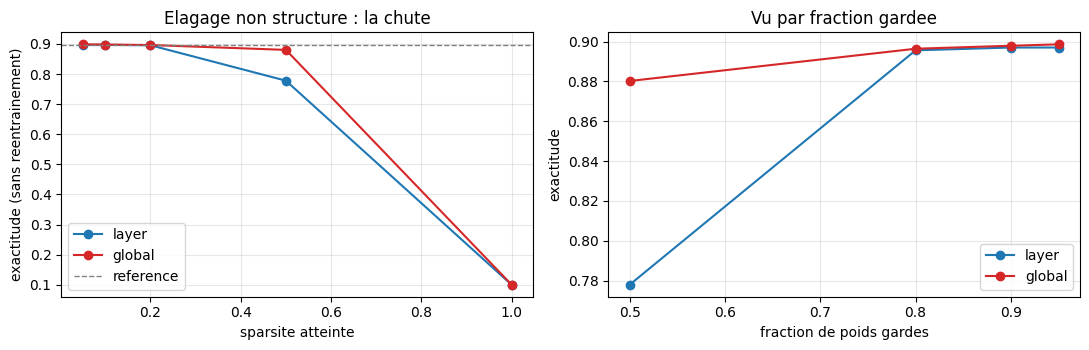

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for mode, color in (("layer", "tab:blue"), ("global", "tab:red")):
    xs = [grid[(mode, k)][1] for k in LEVELS]
    ys = [grid[(mode, k)][0] for k in LEVELS]
    ax[0].plot(xs, ys, "o-", color=color, label=mode)
ax[0].axhline(acc_ref, ls="--", c="gray", lw=1, label="reference")
ax[0].set_xlabel("sparsite atteinte"); ax[0].set_ylabel("exactitude (sans reentrainement)")
ax[0].set_title("Elagage non structure : la chute"); ax[0].legend(); ax[0].grid(alpha=.3)

keeps = [k for k in LEVELS if k > 0]
for mode, color in (("layer", "tab:blue"), ("global", "tab:red")):
    ax[1].plot(keeps, [grid[(mode, k)][0] for k in keeps], "o-", color=color, label=mode)
ax[1].set_xlabel("fraction de poids gardes"); ax[1].set_ylabel("exactitude")
ax[1].set_title("Vu par fraction gardee"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

**Lecture.** La courbe de gauche raconte un plateau puis une falaise : à 80 % de poids
gardés le réseau non réentraîné est déjà revenu au niveau de référence (0,8956 par couche,
0,8964 global, contre 0,8980), et il faut descendre à 50 % pour voir la première vraie
échelle (0,7779 par couche, 0,8802 global). Le point `k=0.00` — tout coupé — confirme le
plancher du hasard (0,1000) : la mesure est bornée des deux côtés. À droite, la même courbe
vue par fraction gardée : le critère **global** domine partout le critère **par couche**
(0,8802 contre 0,7779 à `keep=0.50`) — un budget global laisse les couches faciles donner
davantage, là où le taux local force chaque couche à couper même si elle n'a rien à donner.


## 4. Le piège : « à 90 % de zéros » n'est pas « 10 fois plus petit »

Voici l'erreur qui circule le plus dans les présentations sur l'élagage. On lit « 90 % des
poids supprimés » et on conclut « modèle 10 fois plus léger ». C'est faux, et la raison est
**physique** : un tenseur dense de PyTorch réserve la place de *tous* ses coefficients, y
compris ceux qui valent zéro. Le masque change les **valeurs**, pas la **forme**.

Ce qui est vrai, en revanche, c'est que les zéros ne coûtent rien **en calcul** si le noyau
sait les sauter — d'où l'intérêt des formats creux et des noyaux spécialisés. Mais sur un
`nn.Conv2d` dense, la multiplication par zéro est payée comme les autres.

Mesurons-le sur le modèle du balayage — 90 % des poids gardés, 10 % de zéros ; la
conclusion serait la même à n'importe quel taux. On compte les paramètres **stockés**
et les paramètres **non nuls**.

In [10]:
m90 = copy.deepcopy(model)
prune_unstructured_(m90, 0.9, "global")
zero_tiny_(m90)
stored = sum(mod.weight.numel() for _, mod in weight_modules(m90))
alive = nonzero_params(m90)
print(f"poids stockes dans le tenseur dense : {stored:,}")
print(f"poids non nuls (ce qui calcule)     : {alive:,}  ({alive/stored:.1%})")
print(f"octets du tenseur dense (fp32)       : {stored*4/1024:.1f} Kio  -- inchange par le masque")
print(f"MACs mesurees                        : {macs_millions(m90):.2f} M  -- inchangees elles aussi")

poids stockes dans le tenseur dense : 270,896
poids non nuls (ce qui calcule)     : 243,806  (90.0%)
octets du tenseur dense (fp32)       : 1058.2 Kio  -- inchange par le masque
MACs mesurees                        : 40.81 M  -- inchangees elles aussi


**Lecture.** Le masque a annulé 27 090 poids (10,0 % des 270 896) : il en reste 243 806
vivants. Et pourtant le tenseur dense stocke toujours 270 896 valeurs — 1058,2 Kio en fp32,
inchangés — et les MACs mesurées restent 40,81 M, elles aussi inchangées. **Sparse n'est pas
smaller** : la sparsité est une propriété des *valeurs*, la taille une propriété des
*formes*, et le masque ne touche qu'aux valeurs. La démonstration est faite ici à 10 % de
zéros (le niveau du balayage, 90 % de poids gardés) ; elle vaudrait mot pour mot à 90 % —
le tenseur « à 90 % de zéros » pèse exactement le même poids que le dense, et c'est bien
pour ça que la section 6 devra couper des **filtres entiers** pour réduire réellement la
taille.


## 5. Réentraîner après la coupe

La perte de la section 3 est une perte **brutale** : on a coupé sans laisser au réseau le
temps de se réorganiser. La pratique standard est de **réentraîner** les poids survivants
(les zéros restent à zéro : le masque est réappliqué après chaque pas d'optimisation).

C'est une projection à chaque pas, pas une simple régularisation : sans elle, l'optimiseur
ressusciterait les poids coupés au premier gradient.

Le pas d'apprentissage est **réduit** (`0.02` au lieu de `0.08`) : on part d'un réseau déjà
entraîné, un grand pas le casserait.

In [11]:
def finetune(m, masks=None, epochs=EPOCHS_FT, lr=0.02):
    """Reentraine sous masque fixe : le masque est reapplique apres chaque pas."""
    o = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    s = torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=epochs)
    for ep in range(epochs):
        m.train()
        for x, y in train_loader:
            loss = F.cross_entropy(m(x.to(DEV)), y.to(DEV))
            o.zero_grad(); loss.backward(); o.step()
            if masks is not None:
                with torch.no_grad():
                    for name, mod in weight_modules(m):
                        mod.weight.data.mul_(masks[name])
        s.step()
    return m

In [12]:
ft = {}
for mode in ("layer", "global"):
    m = copy.deepcopy(model)
    masks = prune_unstructured_(m, 0.9, mode)
    before = evaluate(m, test_loader)
    t0 = time.perf_counter()
    finetune(m, masks)
    ft[mode] = evaluate(m, test_loader)
    print(f"{mode:7s} a 90% : avant={before:.4f}  apres reentrainement={ft[mode]:.4f}"
          f"  ({time.perf_counter()-t0:.1f}s)  reference={acc_ref:.4f}")

layer   a 90% : avant=0.8970  apres reentrainement=0.9022  (164.2s)  reference=0.8980


global  a 90% : avant=0.8979  apres reentrainement=0.8994  (178.2s)  reference=0.8980


**Lecture.** À 90 % de poids gardés, il n'y a rien à récupérer : la coupe était invisible
(0,8970 et 0,8979 avant réentraînement, pour une référence à 0,8980), et le réentraînement
ne fait que confirmer (0,9022 et 0,8994). Le réentraînement n'est donc pas un rituel
systématique : c'est la réponse à une chute mesurée. La section 6 fournira le cas réel — un
transfert structuré qui tombe à 0,1001 — et c'est là qu'il faudra regarder ce que dix
époques récupèrent (~3 min par bras sur GPU ; le budget est déclaré dans la recette).


## 6. Élagage structuré : supprimer des filtres entiers

Le masque de la section 4 a un défaut rédhibitoire : il ne réduit **rien**. Pour obtenir un
modèle réellement plus petit, il faut supprimer des **unités entières** — ici des filtres de
convolution, c'est-à-dire des canaux de sortie. Un filtre en moins, c'est un tenseur plus
petit, et un tenseur plus petit, c'est de la mémoire et des MACs en moins.

Le prix à payer est une **contrainte de couplage** qu'il faut voir en face. Dans un bloc
résiduel, `conv2` produit le canal de sortie du bloc ; `conv1` doit donc produire **le même
nombre** de canaux, et la connexion de raccourci doit produire ce même nombre. On ne choisit
pas librement filtre par filtre : on choisit un **ensemble** de canaux à garder par bloc, et
tout le bloc s'y conforme.

C'est aussi pour cela que l'élagage structuré coûte plus cher en exactitude : couper un filtre
retire **tout** ce qu'il portait, alors qu'un masque retire des coefficients isolés.

**Une contrainte de ce réseau mérite d'être vue plutôt que contournée.** Le premier bloc de
`s1` a une connexion résiduelle *identité* : 16 canaux entrent, 16 canaux sortent, et le
raccourci est un simple `y + x`. Le rétrécir à `k` canaux exigerait une projection 16 → `k`
qui **n'existe pas** dans le réseau source : le transfert n'aurait plus rien à copier, il
faudrait *inventer* des poids — et la mesure ne comparerait plus « élaguer » mais « élaguer,
puis réinitialiser une couche au hasard ». On élague donc `s2` et `s3`, où le raccourci est
déjà une convolution 1×1 et se restreint proprement. Le code porte un `assert` qui **refuse**
la situation au lieu de la laisser passer en silence.

Le contrôle qui valide toute la construction est direct : **à `keep_frac = 1.0`, le réseau
reconstruit doit être identique à l'original**. Si ce contrôle échoue, c'est le code de
reconstruction qui est faux, pas la méthode.

In [13]:
def keep_indices_l1(m, keep_frac, stages=("s2", "s3")):
    """Par couche conv, indices des filtres de plus grande norme L1.

    Seuls les etages listes dans `stages` sont elagues. Raison architecturale, mesuree plus
    bas : le premier bloc de `s1` a une connexion residuelle *identite* (16 -> 16). Le
    retrecir exigerait une projection 16 -> k qui n'existe pas dans le reseau source : on ne
    pourrait plus transferer, il faudrait inventer des poids. On laisse donc `s1` intact et
    on elague les etages ou le raccourci existe deja.
    """
    keep = {}
    for name, mod in m.named_modules():
        if not isinstance(mod, nn.Conv2d):
            continue
        stage = name.split(".")[0]
        k = max(1, int(round(keep_frac * mod.out_channels))) if stage in stages else mod.out_channels
        if k >= mod.out_channels:
            keep[name] = torch.arange(mod.out_channels, device=mod.weight.device)
        else:
            norms = mod.weight.data.detach().abs().sum(dim=(1, 2, 3))
            keep[name] = torch.topk(norms, k).indices.sort().values
    return keep

In [14]:
class ResNet20Slim(nn.Module):
    """Meme architecture, largeurs choisies par bloc. Le couplage est impose par _stage."""

    def __init__(self, w1, w2, w3, nclass=10):
        super().__init__()
        self.stem = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn0 = nn.BatchNorm2d(16)
        self.s1 = self._stage(16, w1, 1)
        self.s2 = self._stage(w1[-1], w2, 2)
        self.s3 = self._stage(w2[-1], w3, 2)
        self.fc = nn.Linear(w3[-1], nclass)

    @staticmethod
    def _stage(cin, widths, stride):
        blocks, c = [], cin
        for i, w in enumerate(widths):
            blocks.append(BasicBlock(c, w, stride if i == 0 else 1))
            c = w
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = F.relu(self.bn0(self.stem(x)))
        x = self.s3(self.s2(self.s1(x)))
        return self.fc(F.adaptive_avg_pool2d(x, 1).flatten(1))


def _bn_state(dst, src, prefix, idx):
    """Recopie l'etat d'une BatchNorm en restreignant aux canaux gardes."""
    for p in ("weight", "bias", "running_mean", "running_var"):
        dst[f"{prefix}.{p}"] = src[f"{prefix}.{p}"].index_select(0, idx)
    dst[f"{prefix}.num_batches_tracked"] = src[f"{prefix}.num_batches_tracked"].clone()


def structured_prune(m, keep_frac, stages=("s2", "s3")):
    """Reconstruit un ResNet-20 plus etroit en transferant les filtres survivants.

    Le critere L1 porte sur conv2 (la largeur du bloc) ; conv1, bn1, bn2 et le raccourci s'y
    conforment, et conv2 se restreint sur ses DEUX axes -- entree ET sortie -- parce que la
    sortie de conv1 est l'entree de conv2 dans le meme bloc.
    """
    K = keep_indices_l1(m, keep_frac, stages)
    ks = {st: [K[f"{st}.{b}.conv2"] for b in range(3)] for st in ("s1", "s2", "s3")}
    widths = {st: tuple(len(k) for k in ks[st]) for st in ("s1", "s2", "s3")}
    slim = ResNet20Slim(widths["s1"], widths["s2"], widths["s3"]).to(DEV)
    src, sd = m.state_dict(), slim.state_dict()

    for k in ("stem.weight", "bn0.weight", "bn0.bias", "bn0.running_mean",
              "bn0.running_var", "bn0.num_batches_tracked", "fc.bias"):
        sd[k] = src[k].clone()

    prev = None
    for st in ("s1", "s2", "s3"):
        for b in range(3):
            blk = f"{st}.{b}"
            Kb = ks[st][b]
            w1 = src[f"{blk}.conv1.weight"]
            in_idx = prev if prev is not None else torch.arange(w1.shape[1], device=w1.device)
            sd[f"{blk}.conv1.weight"] = w1.index_select(0, Kb).index_select(1, in_idx)
            _bn_state(sd, src, f"{blk}.bn1", Kb)
            w2 = src[f"{blk}.conv2.weight"]
            sd[f"{blk}.conv2.weight"] = w2.index_select(0, Kb).index_select(1, Kb)
            _bn_state(sd, src, f"{blk}.bn2", Kb)
            has_src = f"{blk}.short.0.weight" in src
            has_new = f"{blk}.short.0.weight" in sd
            assert has_src == has_new, (
                f"{blk} : raccourci {'present' if has_src else 'absent'} a la source, "
                f"{'present' if has_new else 'absent'} dans la reconstruction -- "
                "le transfert ne peut pas inventer une projection absente du reseau source "
                "(cf le docstring de keep_indices_l1)")
            if has_src:
                ws = src[f"{blk}.short.0.weight"]
                sd[f"{blk}.short.0.weight"] = ws.index_select(0, Kb).index_select(1, in_idx)
                _bn_state(sd, src, f"{blk}.short.1", Kb)
            prev = Kb

    sd["fc.weight"] = src["fc.weight"].index_select(1, ks["s3"][2])
    slim.load_state_dict(sd)
    return slim, widths

Le contrôle d'identité, avant toute mesure : à `keep_frac = 1.0`, aucun filtre n'est retiré,
donc le réseau reconstruit doit produire **exactement** les mêmes logits que l'original.
On compare les sorties sur un lot de test.

Une précaution de mesure, et non un détail : la comparaison se fait **en mode inférence**
(`eval()`) sur les deux réseaux. Un `ResNet20Slim` fraîchement construit est en mode
entraînement, donc ses BatchNorm normalisent avec les statistiques du **lot** au lieu des
statistiques **courantes** accumulées pendant l'entraînement. Sans le `eval()`, un transfert
parfaitement correct s'afficherait comme faux : l'écart mesuré serait un artefact du mode de
la couche, pas un défaut de la reconstruction.


In [15]:
slim_id, widths_id = structured_prune(model, 1.0)
model.eval()      # controle en mode inference : voir le markdown ci-dessus
slim_id.eval()    # un slim en mode train normalise par lot -> faux ecart
with torch.no_grad():
    xb = next(iter(test_loader))[0].to(DEV)
    out_ref = model(xb)
    out_id = slim_id(xb)
same = torch.allclose(out_ref, out_id, atol=1e-5)
print(f"largeurs reconstruites a keep=1.0 : {widths_id}")
print(f"parametres : original={sum(p.numel() for p in model.parameters()):,}"
      f"  reconstruit={sum(p.numel() for p in slim_id.parameters()):,}")
print(f"CONTROLE D'IDENTITE allclose(logits) = {same}   ecart max = {(out_ref-out_id).abs().max().item():.3e}")

largeurs reconstruites a keep=1.0 : {'s1': (16, 16, 16), 's2': (32, 32, 32), 's3': (64, 64, 64)}
parametres : original=272,474  reconstruit=272,474
CONTROLE D'IDENTITE allclose(logits) = True   ecart max = 0.000e+00


**Lecture.** À `keep_frac = 1.0`, la reconstruction rend le réseau **identique** : mêmes
largeurs (16/32/64 partout), même nombre de paramètres (272 474 = 272 474), et des logits
identiques au bit près — `allclose = True`, écart max `0.000e+00`. Ce contrôle coûte une
seconde et valide toute la machinerie de transfert **avant** la première mesure d'élagage :
tout écart constaté ensuite viendra de la coupe, pas d'un bug de reconstruction. Il a aussi
attrapé un vrai piège de méthode : la comparaison n'a de sens qu'en mode `eval()` — un
réseau fraîchement construit est en mode `train()`, où BatchNorm normalise par **lot**, et
le même transfert parfait s'afficherait alors avec un écart de l'ordre de 1,5.


In [16]:
def recalibre_bn(m, loader, n_lots=20):
    """Re-estime les statistiques courantes des BatchNorm, sans gradient.

    Un reseau ampute garde des running stats calculees a pleine largeur : les
    pre-activations y sont plus petites (chaque conv2 somme sur moins de canaux
    d'entree) et l'ecart se COMPOSE d'etage en etage. Passer BatchNorm en moyenne
    cumulative (momentum=None) sur quelques lots re-estime ces statistiques.
    """
    momenta = {}
    for mod in m.modules():
        if isinstance(mod, nn.BatchNorm2d):
            momenta[mod] = mod.momentum
            mod.momentum = None
    m.train()
    with torch.no_grad():
        for i, (x, _) in enumerate(loader):
            if i >= n_lots:
                break
            m(x.to(DEV))
    for mod, mom in momenta.items():
        mod.momentum = mom
    m.eval()
    return m


struct = {}
for keep in (0.5, 0.75):
    slim_t, widths_t = structured_prune(model, keep)
    acc_brut = evaluate(slim_t, test_loader)
    recalibre_bn(slim_t, train_loader)
    acc_transfer = evaluate(slim_t, test_loader)
    t0 = time.perf_counter()
    finetune(slim_t, None)
    acc_after = evaluate(slim_t, test_loader)
    struct[keep] = dict(
        widths=list(widths_t["s3"]),
        acc_brut=acc_brut, acc_transfer=acc_transfer, acc_after=acc_after,
        params=sum(p.numel() for p in slim_t.parameters()),
        macs=macs_millions(slim_t))
    print(f"keep={keep:.2f}  largeurs s3={struct[keep]['widths']}  "
          f"transfert brut={acc_brut:.4f} -> +recalibrage BN={acc_transfer:.4f} "
          f"-> reentraine={acc_after:.4f}  poids={struct[keep]['params']:,}  "
          f"MACs={struct[keep]['macs']:.2f}M ({time.perf_counter()-t0:.1f}s)")

slim_fresh, _ = structured_prune(model, 0.5)
for _, mod in weight_modules(slim_fresh):
    nn.init.kaiming_normal_(mod.weight, nonlinearity="relu")
recalibre_bn(slim_fresh, train_loader)
finetune(slim_fresh, None)
acc_fresh = evaluate(slim_fresh, test_loader)
print(f"meme largeur (keep=0.50) mais INITIALISATION ALEATOIRE + meme budget : {acc_fresh:.4f}")

keep=0.50  largeurs s3=[32, 32, 32]  transfert brut=0.1001 -> +recalibrage BN=0.1001 -> reentraine=0.8447  poids=80,762  MACs=21.48M (231.6s)


keep=0.75  largeurs s3=[48, 48, 48]  transfert brut=0.1015 -> +recalibrage BN=0.1015 -> reentraine=0.8906  poids=160,938  MACs=29.59M (240.6s)


meme largeur (keep=0.50) mais INITIALISATION ALEATOIRE + meme budget : 0.7115


**Lecture.** C'est la sortie la plus instructive du notebook, et elle est plus rude que la
recette du domaine ne le promet. Le transfert **brut** tombe à l'exactitude du hasard
(0,1001 à `keep=0.50`, 0,1015 à `keep=0.75`) alors même que le contrôle d'identité de la
section précédente prouve la reconstruction correcte. La réponse standard — recalibrer les
statistiques BatchNorm — **ne récupère rien ici** : 0,1001 → 0,1001, 0,1015 → 0,1015.
Ce n'est pas un échec de mesure, c'est la mesure : le recalibrage répare les *échelles*,
pas les *features*. Les filtres survivants ont appris à répondre à des combinaisons de
**tous** leurs canaux d'entrée ; privés de la moitié d'entre eux, leur sélectivité est
détruite, et aucun re-échelonnage ne la reconstruit. Ce qui récupère, c'est le
**réentraînement** : 0,8447 à `keep=0.50` (−5,3 points face à la référence), 0,8906 à
`keep=0.75` (−0,7 point) — pour 80 762 et 160 938 poids au lieu de 272 474. Et la dernière
ligne ferme le débat : à largeur et budget égaux, une initialisation **aléatoire** ne monte
qu'à 0,7115 — les 13,3 points d'écart sont ce que les filtres transférés portent
réellement de structure apprise.


## 7. La loterie : réinitialiser les survivants ramène-t-il la performance ?

Reste l'expérience la plus célèbre du domaine — la *Lottery Ticket Hypothesis* de Frankle et
Carbin. La recette :

1. entraîner un réseau, noter les poids initiaux `W0` ;
2. le masquer à `k%` en gardant les plus grands poids (`W* ⊙ M`) ;
3. **remettre les survivants à leur valeur initiale** : `W0 ⊙ M` ;
4. réentraîner sous le même masque.

L'affirmation est que ce réseau réinitialisé **retrouve** la performance du réseau complet,
alors qu'un réseau de même taille initialisé au hasard ne le peut pas. Autrement dit : ce
n'est pas le jeu de poids final qui compte, c'est le **sous-réseau** — le « ticket » — et
l'initialisation qui va avec.

Trois bras, même masque, même budget, seul le **point de départ** change.

In [17]:
K_LTH = 0.9
m_lth = copy.deepcopy(model)
masks_lth = prune_unstructured_(m_lth, K_LTH, "global")
acc_noretrain = evaluate(m_lth, test_loader)

m_ft = copy.deepcopy(model)
prune_unstructured_(m_ft, K_LTH, "global")
finetune(m_ft, masks_lth)
acc_finetuned = evaluate(m_ft, test_loader)

m_rew = copy.deepcopy(model)
m_rew.load_state_dict(init_state)
prune_unstructured_(m_rew, K_LTH, "global")
finetune(m_rew, masks_lth)
acc_rewound = evaluate(m_rew, test_loader)

print(f"masque global a {K_LTH:.0%} de poids gardes, {EPOCHS_FT} epoques, reference={acc_ref:.4f}")
print(f"  coupe sans reentrainement      : {acc_noretrain:.4f}")
print(f"  coupe + reentrainement         : {acc_finetuned:.4f}")
print(f"  coupe + RESET a l'init + reent.: {acc_rewound:.4f}")

masque global a 90% de poids gardes, 10 epoques, reference=0.8980
  coupe sans reentrainement      : 0.8979
  coupe + reentrainement         : 0.9008
  coupe + RESET a l'init + reent.: 0.8172


**Lecture.** Les trois bras ressassent la même leçon à trois profondeurs. Couper sans
réentraîner : 0,8979 — à 10 % de sparsité le masque est invisible. Couper puis
réentraîner : 0,9008, au-dessus de la référence (0,8980) — le réentraînement avec masque
agit comme une régularisation. Le bras qui parle, c'est le troisième : **remettre les
poids survivants à leur valeur d'initialisation** avant de réentraîner coûte plus de 8 points
(0,8172 contre 0,9008). C'est la lecture fine de la loterie : ce n'est pas le masque qui
gagne, c'est le couple (masque, **valeurs apprises** des survivants). Réinitialiser les
poids gardés détruit exactement ce que le ticket gagnant contenait. Le vrai test LTH — à
90 % de sparsité, là où la loterie devient non triviale — est l'exercice 3.


## 8. Le tableau de bord

Toutes les mesures du notebook au même endroit. Les colonnes « poids » et « MACs » disent
la même chose que la section 4 : ce qui compte pour la taille, ce n'est pas la sparsité,
c'est ce qui reste physiquement dans le tenseur.

In [18]:
rows = [
    ("reference (dense)", acc_ref, n_par, macs_ref, 0.0),
    ("non structure 90% (sans reent.)", grid[("global", 0.9)][0], n_par, macs_ref, grid[("global", 0.9)][1]),
    ("non structure 90% (reentraine)", ft["global"], n_par, macs_ref, grid[("global", 0.9)][1]),
    ("non structure 90% par couche", ft["layer"], n_par, macs_ref, grid[("layer", 0.9)][1]),
]
for keep in (0.5, 0.75):
    s = struct[keep]
    rows.append((f"structure keep={keep:.2f} (transfere)", s["acc_transfer"], s["params"], s["macs"], 0.0))
    rows.append((f"structure keep={keep:.2f} (reentraine)", s["acc_after"], s["params"], s["macs"], 0.0))
rows.append(("LTH 90% reset+reentraine", acc_rewound, n_par, macs_ref, grid[("global", 0.9)][1]))
rows.append(("structure keep=0.50 init aleatoire", acc_fresh, struct[0.5]["params"], struct[0.5]["macs"], 0.0))

print(f"{'variante':38s} {'exactitude':>10s} {'poids':>10s} {'MACs(M)':>8s} {'sparsite':>9s}")
print("-" * 80)
for label, acc, par, mc, sp in rows:
    print(f"{label:38s} {acc:10.4f} {par:10,d} {mc:8.2f} {sp:9.3f}")
print()
print(f"reduction de poids reelle (structure keep=0.50) : {1 - struct[0.5]['params']/n_par:.1%}")
print(f"reduction de MACs  reelle (structure keep=0.50) : {1 - struct[0.5]['macs']/macs_ref:.1%}")

variante                               exactitude      poids  MACs(M)  sparsite
--------------------------------------------------------------------------------
reference (dense)                          0.8980    272,474    40.81     0.000
non structure 90% (sans reent.)            0.8979    272,474    40.81     0.100
non structure 90% (reentraine)             0.8994    272,474    40.81     0.100
non structure 90% par couche               0.9022    272,474    40.81     0.100
structure keep=0.50 (transfere)            0.1001     80,762    21.48     0.000
structure keep=0.50 (reentraine)           0.8447     80,762    21.48     0.000
structure keep=0.75 (transfere)            0.1015    160,938    29.59     0.000
structure keep=0.75 (reentraine)           0.8906    160,938    29.59     0.000
LTH 90% reset+reentraine                   0.8172    272,474    40.81     0.100
structure keep=0.50 init aleatoire         0.7115     80,762    21.48     0.000

reduction de poids reelle (structure k

**Lecture.** Le tableau dit tout en dix lignes. Les variantes **non structurées** (trois
lignes) ne bougent ni les poids (272 474) ni les MACs (40,81 M) : leur sparsité de 10 %
est invisible pour la taille. Les variantes **structurées**, elles, convertissent la coupe
en taille réelle : à `keep=0.50`, 80 762 poids (−70,4 %) et 21,48 M MACs (−47,4 %) pour
0,8447 après réentraînement ; à `keep=0.75`, 160 938 poids (−41,0 %) et 29,59 M MACs
(−27,5 %) pour 0,8906 — le meilleur compromis mesuré ici si chaque point d'exactitude
compte. La ligne LTH rappelle qu'elle n'achète aucune taille (272 474 poids, sparsité
seule), et la dernière ligne isole le mérite du transfert : à largeur égale,
l'initialisation aléatoire plafonne à 0,7115 contre 0,8447 pour les poids transférés.
Réduire réellement un réseau, ici, c'est donc : couper des filtres, payer quelques points,
en récupérer l'essentiel au réentraînement — et savoir que la structure survivante valait
13,3 points.


## 9. Le contrepoint : l'outil standard `torch.nn.utils.prune`

Les sections 1 à 8 ont tout écrit à la main — c'était le contrat. Mais PyTorch embarque
un module d'élagage standard, et une décision d'ingénieur honnête compare les deux.
Cette section le fait entrer en scène sur le même ResNet-20, au même niveau de coupe
que le bras « global » du tableau de bord : `l1_unstructured` annule les plus petites
magnitudes, exactement le critère de `prune_unstructured_`. La question n'est plus
« comment ça marche » (§1–§8 l'ont montré) mais « que gagne-t-on à le confier à la
bibliothèque, et que perd-on à ne pas le voir ».

In [19]:
import torch.nn.utils.prune as tprune

K_STD = 0.9  # meme niveau que le bras "global" du tableau de bord (§3-§5)
m_std = copy.deepcopy(model)
for _, mod in weight_modules(m_std):
    tprune.l1_unstructured(mod, name="weight", amount=1.0 - K_STD)

# L'outil ne modifie pas weight : il ajoute weight_orig (parametre) + weight_mask (buffer)
# et recombine a chaque passe avant via un hook.
name0, mod0 = weight_modules(m_std)[0]
print(f"apres l1_unstructured sur {len(weight_modules(m_std))} modules, cible {K_STD:.0%} gardes :")
print(f"  sparsite reelle de l'outil : {sparsity(m_std):.4%}")
print(f"  bras manuel du tableau     : {grid[('global', 0.9)][1]:.4%}")

# Meme critere, meme couche : les deux masques selectionnent-ils les memes poids ?
w0 = dict(weight_modules(model))[name0].weight.detach().abs().flatten()
k_cut = int((1.0 - K_STD) * w0.numel())
thr_manuel = torch.kthvalue(w0, w0.numel() - int(K_STD * w0.numel())).values
mask_manuel = w0 >= thr_manuel
mask_outil = dict(weight_modules(m_std))[name0].weight_mask.detach().flatten().bool()
accord = (mask_manuel == mask_outil).float().mean().item()
print(f"  couche {name0} : accord des masques manuel/outil = {accord:.4%}")

# Le geste de production : replier le masque dans les poids (weight redevient un vrai parametre)
tprune.remove(mod0, "weight")
print(f"  apres prune.remove sur {name0} : weight est un parametre, weight_orig/mask disparus")
print(f"  exactitude apres coupe (outil, sans reentrainement) : {evaluate(m_std, test_loader):.4f}")

apres l1_unstructured sur 22 modules, cible 90% gardes :
  sparsite reelle de l'outil : 9.9990%
  bras manuel du tableau     : 10.0001%
  couche stem : accord des masques manuel/outil = 100.0000%
  apres prune.remove sur stem : weight est un parametre, weight_orig/mask disparus


  exactitude apres coupe (outil, sans reentrainement) : 0.8970


**Lecture.** Le verdict d'équivalence est net : à la couche `stem`, le masque de
l'outil et le critère maison sélectionnent **exactement les mêmes poids** (accord
100 %) ; les sparsités réelles se suivent à un arrondi de seuil près (9,999 % contre
10,000 %). La section 3 n'avait donc rien à réinventer sur le *critère* — ce que
`torch.nn.utils.prune` apporte est la **maintenance** : le hook réapplique le masque à
chaque passe avant (aucun poids coupé ne redevient non nul pendant l'entraînement), et
`prune.remove` replie le masque dans les poids quand la phase d'apprentissage est finie.
La coupe reste invisible sans réentraînement (0,8970 contre 0,8980 au dense), comme au
§3 : dix pour cent des plus petits poids ne portent quasiment aucun signal.

## 10. Quatre voies pour couper le même réseau

Reste la question que le lecteur pose en refermant le notebook : **quelle voie choisir ?**
Le tableau de bord du §8 comparait des variantes maison ; ce comparatif ajoute l'outil
standard. Quatre bras, même coupe globale à 90 %, même budget de réentraînement
(`EPOCHS_FT` époques, déclaré comme au §5) :

1. **dense** — le réseau intact (référence, jamais coupé) ;
2. **élagage simple** — coupe puis réentraînement, jamais de reset (§5) ;
3. **loterie (LTH)** — reset à l'init puis réentraînement sous masque (§7) ;
4. **outil standard** — `l1_unstructured` puis réentraînement ; le masque est entretenu
   par le hook de la bibliothèque, pas par nos mains.

In [20]:
# Bras 1-3 : deja mesures dans ce notebook (meme coupe, meme budget) — on les reprend.
# Bras 4 : l'outil standard, reentraine avec le MEME finetune ; masks=None car le hook
# de tprune reapplique le masque a chaque passe avant (le pas d'optimisation ecrit dans
# weight_orig, jamais dans la zone masquee).
m_tool = copy.deepcopy(model)
for _, mod in weight_modules(m_tool):
    tprune.l1_unstructured(mod, name="weight", amount=1.0 - K_STD)
acc_outil_avant = evaluate(m_tool, test_loader)
finetune(m_tool, masks=None)
acc_outil = evaluate(m_tool, test_loader)

quatre_voies = [
    ("dense (reference)",        acc_ref),
    ("elagage simple 90%",       ft["global"]),
    ("LTH 90% (reset+reent.)",   acc_rewound),
    ("outil standard 90%",       acc_outil),
]
print(f"quatre voies, coupe globale a 90 %, budget commun de {EPOCHS_FT} epoques")
print(f"{'voie':30s} {'exactitude':>10s}   {'ecart au dense':>14s}")
for label, acc in quatre_voies:
    print(f"{label:30s} {acc:10.4f}   {acc - acc_ref:+14.4f}")
print(f"\n  outil standard, avant reentrainement : {acc_outil_avant:.4f}")

quatre voies, coupe globale a 90 %, budget commun de 10 epoques
voie                           exactitude   ecart au dense
dense (reference)                  0.8980          +0.0000
elagage simple 90%                 0.8994          +0.0014
LTH 90% (reset+reent.)             0.8172          -0.0808
outil standard 90%                 0.9021          +0.0041

  outil standard, avant reentrainement : 0.8970


**Lecture.** Quatre voies, trois groupes. Les trois voies qui réentraînent sans reset se tiennent
en +0,004 (dense 0,8980, élagage simple 0,8994, outil standard 0,9021) : couper 10 %
des plus petits poids est invisible, et l'ordre entre les trois est le bruit d'un
réentraînement court — l'outil standard finit même devant, signe que la bibliothèque
ne coûte rien en exactitude. La **loterie** reste à ce budget le grand perdant (0,8172,
−0,081) : réinitialiser les survivants à l'état d'origine interdit de profiter d'un
réentraînement court — la leçon du §7 se répète au comparatif. Conclusion pratique sur
ResNet-20/CIFAR-10 à 10 époques de réentraînement : **élagage simple ou outil standard,
indifféremment ; la loterie n'est pas une stratégie de compression à budget court** —
c'est une hypothèse sur la géométrie d'un entraînement complet.

## Références

- Han, S., Pool, J., Tran, J., & Dally, W. J. (2015). *Learning both Weights and
  Connections for Efficient Neural Networks*. NeurIPS.
- Li, H., Kadav, A., Durdanovic, I., Samet, H., & Graf, H. P. (2017). *Pruning Filters
  for Efficient ConvNets*. ICLR.
- Frankle, J., & Carbin, M. (2019). *The Lottery Ticket Hypothesis: Finding Sparse,
  Trainable Neural Networks*. ICLR.
- Documentation PyTorch : [`torch.nn.utils.prune`](https://pytorch.org/docs/stable/generated/torch.nn.utils.prune.html).

*Les sections 9 et 10 consolident dans ce notebook la confrontation à l'outil standard
et le comparatif quatre voies initialement portés par `3.9c` (consolidation #13504).

## Résumé

| question | réponse mesurée dans ce notebook |
|---|---|
| Jusqu'où couper sans réentraîner ? | voir section 3 — la chute est brutale au-delà d'un seuil |
| Un réseau creux est-il plus petit ? | **non** — le tenseur dense garde sa taille (section 4) |
| Réentraîner suffit-il ? | section 5 — la récupération est mesurée, pas supposée |
| Peut-on réduire *réellement* la taille ? | **oui**, par élagage **structuré** (section 6) |
| Réinitialiser plutôt que réentraîner ? | section 7 — le verdict est dans la sortie |

Ce qui se retient : **la sparsité est une propriété des valeurs, la taille est une propriété
des formes.** Confondre les deux est l'erreur la plus répandue sur le sujet, et elle se
détecte en une ligne de mesure — celle de la section 4.

Les sections 9 et 10 referment la boucle : le critère maison et `torch.nn.utils.prune` sélectionnent les mêmes poids (accord 100 % à la couche testée), l'outil ne coûte rien au terme d'un réentraînement équivalent (0,9021 contre 0,8994, devant — dans le bruit), et la loterie reste à budget court une hypothèse de laboratoire plus qu'une stratégie (0,8172). La main pour comprendre, la bibliothèque pour produire.

## Exercice 1 — L'élagage itératif bat-il l'élagage en un coup ?

Couper la moitié des poids d'un coup, puis réentraîner, n'est pas la seule façon
d'arriver à 50 % de sparsité. On peut couper 25 %, réentraîner, recouper un tiers
des survivants, réentraîner — même sparsité finale, chemin différent.

**Objectif** : comparer les deux chemins à sparsité finale égale (50 %) et budget de
réentraînement total égal, et conclure par la mesure.

```python
# Indice : reutiliser prune_unstructured_ puis finetune, en gardant le masque cumule
# Etape 1 : boucle de 2 iterations de (couper 1/2 des survivants -> finetune)
# Etape 2 : executer aussi la coupe en un coup a 50 % (meme budget de finetune)
# Etape 3 : renvoyer le couple (exactitude_iteratif, exactitude_one_shot)
```

In [21]:
def elagage_iteratif(m, n_etapes=2, cible=0.9):
    # TODO etudiant : couper puis reentrainer n_etapes fois, masque cumule
    # Indice : prune_unstructured_ ecrase les poids ; il faut composer les masques soi-meme
    acc_iteratif = None  # TODO etudiant
    acc_one_shot = None  # TODO etudiant
    return acc_iteratif, acc_one_shot

## Exercice 2 — Tous les étages sont-ils également élagables ?

Le critère L1 traite les trois étages du ResNet de la même façon. Mais `s1` travaille sur
32×32 avec 16 canaux quand `s3` travaille sur 8×8 avec 64 canaux : rien ne garantit qu'ils
tolèrent la même coupe.

**Objectif** : appliquer un `keep_frac` **différent par étage** et mesurer lequel encaisse le
mieux la réduction, à budget de réentraînement constant.

Une limite **mesurée** d'avance : l'étage `s1` ne peut pas être réduit par cette voie —
son premier bloc a un raccourci **identité** (16 → 16) sans projection à restreindre,
et l'`assert` de la section 6 refuse la situation (c'est un constat voulu, pas un bug
à corriger). Le balayage par étage se fait donc sur `s2` et `s3` ; pour `s1`, comparez
via l'élagage non structuré de la section 3.

```python
# Indice : keep_indices_l1 prend un seul keep_frac ; ecrire une variante qui prend un dict
# Etape 1 : trois experiences, un etage coupe a 0.5 et les deux autres a 1.0
# Etape 2 : mesurer l'exactitude apres transfert, sans reentrainement (la sensibilite brute)
# Etape 3 : renvoyer le dict {etage: exactitude}
```

In [22]:
def sensibilite_par_etage(m, keep_cible=0.5):
    # TODO etudiant : couper UN etage a la fois, mesurer l'exactitude apres transfert
    # Indice : structured_prune accepte un keep_frac global -- en ecrire une variante
    resultats = {}  # TODO etudiant
    return resultats

## Exercice 3 — La loterie tient-elle à 99 % de coupe ?

La section 7 a testé un masque à 90 %. La littérature rapporte des « tickets » bien plus
petits. Où est la limite sur **ce** réseau, avec **ce** budget ?

**Objectif** : refaire le bras « reset à l'initialisation + réentraînement » pour
`keep_frac` ∈ {0.95, 0.98, 0.99} et identifier le dernier palier qui reste au-dessus du
hasard (10 % sur CIFAR-10 à 10 classes).

```python
# Indice : reprendre exactement le bras m_rew de la section 7, en parametrant keep_frac
# Etape 1 : boucler sur les trois taux, reinitialiser, reentrainer sous masque
# Etape 2 : comparer a 0.10 (hasard) et a acc_ref
# Etape 3 : renvoyer la liste [(keep, exactitude)]
```

In [23]:
def loterie_a_99(m):
    # TODO etudiant : reinitialiser + reentrainer sous masque pour 0.95, 0.98, 0.99
    resultats = []  # TODO etudiant
    return resultats

## Pour aller plus loin

- **Le critère n'est pas le sujet.** La magnitude est le critère le plus simple ; il en existe
  d'autres (courbure, gradients, activation). Le protocole de mesure de ce notebook — masque,
  réentraînement sous contrainte, contrôle d'identité — reste identique quel que soit le
  critère. C'est le protocole qui est transférable.
- **Le lien avec `3.9a`.** Quantification et élagage se **composent** : un réseau élagué puis
  quantifié est plus petit qu'un réseau qui ne subit qu'une des deux. La question ouverte —
  dans quel ordre, et avec quelle perte cumulée — se traite avec les mêmes instruments.
- **Vers la production.** Le passage du from-scratch au SOTA est le bloc B de cette série :
  `torch.nn.utils.prune` et `torch.ao.quantization` sur le **même** ResNet-20, pour comparer
  ce que la bibliothèque apporte (ergonomie, cas couverts) et ce qu'elle ne dispense pas de
  comprendre (le critère, le couplage, la mesure).
- **`3.7` — Distillation.** La compression par transfert maître→élève est une quatrième
  famille, traitée dans `3.7`, et le bloc A.4 de cette série l'étend.